<a href="https://colab.research.google.com/github/MythryeeA/Real-Vs-Fake-News-Detection/blob/main/NM_fake_newsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Step 1: Load the individual CSV files
true_df = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')
fake_df = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')

# Step 2: Add a 'label' column to each dataframe
true_df['label'] = 'TRUE'   # Label all true news
fake_df['label'] = 'FAKE'   # Label all fake news

# Step 3: Combine both dataframes into one
news_df = pd.concat([true_df, fake_df], ignore_index=True)

# Step 4: Save the combined dataframe into a new CSV file
news_df.to_csv('news.csv', index=False)

print("Combined and labeled file saved as news.csv")

Combined and labeled file saved as news.csv


In [2]:
df=pd.read_csv('/content/news.csv')
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",TRUE
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",TRUE
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",TRUE
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",TRUE
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",TRUE
...,...,...,...,...,...
29448,Harry Reid UNLEASHES Anti-Trump Rant On Senat...,Senate Minority Leader Harry Reid has it out f...,News,"September 15, 2016",FAKE
29449,Respected Forensic Pathologist Suggests Trump...,Hillary Clinton shocked America a few days ago...,News,"September 15, 2016",FAKE
29450,Heckler Screams ‘F*ck Hillary’ At Clinton Ral...,Sometimes you ve got to laugh especially if ...,News,"September 15, 2016",FAKE
29451,WATCH: Flint Pastor Who Shut Trump Down Hits ...,If Donald Trump thought he was going to get aw...,News,"September 15, 2016",FAKE


**Data Preprocessing**

In [3]:
df.shape

(29453, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29453 entries, 0 to 29452
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    29453 non-null  object
 1   text     29453 non-null  object
 2   subject  29453 non-null  object
 3   date     29453 non-null  object
 4   label    29453 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


In [5]:
df.describe()

,title,text,subject,date,label
count,29453,29453,29453,29453,29453
unique,26235,26608,3,1238,2
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017",TRUE
freq,14,8,11272,182,21417


In [6]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [7]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset
df = pd.read_csv("news.csv")

# Display basic structure
print("Initial shape:", df.shape)
print("Columns:", df.columns)

# Step 1: Format the 'date' column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Step 2: Encode the 'label' column (e.g., FAKE -> 0, TRUE -> 1)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# Step 3: Encode the 'subject' column
df['subject_encoded'] = label_encoder.fit_transform(df['subject'])

# Step 4: Define manual stopwords (avoids downloading NLTK resources)
manual_stopwords = {
    'the', 'and', 'is', 'in', 'to', 'of', 'for', 'on', 'with', 'as', 'by',
    'at', 'from', 'that', 'this', 'an', 'it', 'be', 'are', 'was', 'were',
    'or', 'which', 'a', 'but', 'not', 'have', 'has', 'had', 'they', 'their',
    'you', 'i', 'we', 'he', 'she', 'his', 'her', 'them', 'its', 'will', 'would',
    'can', 'could', 'should', 'may', 'might', 'about', 'into', 'over', 'after',
    'before', 'during', 'more', 'most', 'some', 'such', 'no', 'nor', 'only'
}

# Step 5: Define a basic text cleaning function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in manual_stopwords]
    return ' '.join(tokens)

# Step 6: Apply cleaning to 'title' and 'text'
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)

# Step 7: TF-IDF vectorization on the cleaned text
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

# Optional: Check outputs
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print(df[['clean_title', 'clean_text', 'subject_encoded', 'label']].head())


Initial shape: (29453, 5)
Columns: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
TF-IDF matrix shape: (29453, 5000)
                                         clean_title  \
0  us budget fight looms republicans flip fiscal ...   
1  us military accept transgender recruits monday...   
2  senior us republican senator let mr mueller do...   
3  fbi russia probe helped australian diplomat ti...   
4  trump wants postal service charge much amazon ...   

                                          clean_text  subject_encoded  label  
0  washington reuters head conservative republica...                1      1  
1  washington reuters transgender people allowed ...                1      1  
2  washington reuters special counsel investigati...                1      1  
3  washington reuters trump campaign adviser geor...                1      1  
4  seattlewashington reuters president donald tru...                1      1  


**Feature Engineering**

**Model Building**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy: 0.9930402308606349
Precision: 0.9921785139176443
Recall: 0.9983796296296297
F1-score: 0.9952694127148956
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1571
           1       0.99      1.00      1.00      4320

    accuracy                           0.99      5891
   macro avg       0.99      0.99      0.99      5891
weighted avg       0.99      0.99      0.99      5891



In [9]:
print("Train Accuracy:", log_model.score(X_train, y_train))
print("Test Accuracy:", log_model.score(X_test, y_test))


Train Accuracy: 0.9971139971139971
Test Accuracy: 0.9930402308606349


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


=== Decision Tree Classifier ===
Accuracy: 0.9986419962654898
Precision: 0.9992993928070995
Recall: 0.9988328664799253
F1-score: 0.9990660751809479

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      5891
   macro avg       1.00      1.00      1.00      5891
weighted avg       1.00      1.00      1.00      5891



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Train-test split (if not already done)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


=== Random Forest Classifier ===
Accuracy: 0.9998302495331862
Precision: 0.9997666277712952
Recall: 1.0
F1-score: 0.9998833002684094

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      5891
   macro avg       1.00      1.00      1.00      5891
weighted avg       1.00      1.00      1.00      5891



In [12]:
#saving the model
import joblib
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

**Visualization of Results & Model Insights**

In [13]:
#importing necessary dependencies
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import numpy as np
import pandas as pd


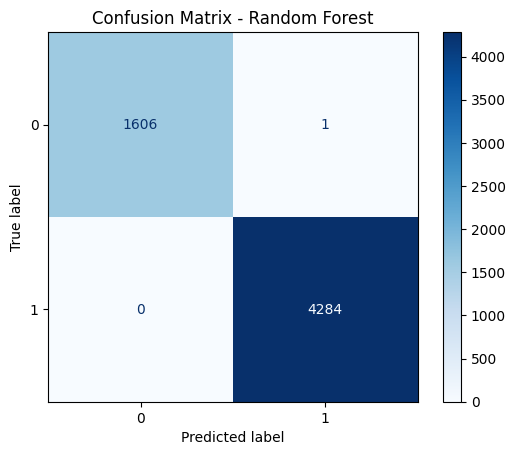

In [14]:
#Using plots and charts to explain model behavior
#confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

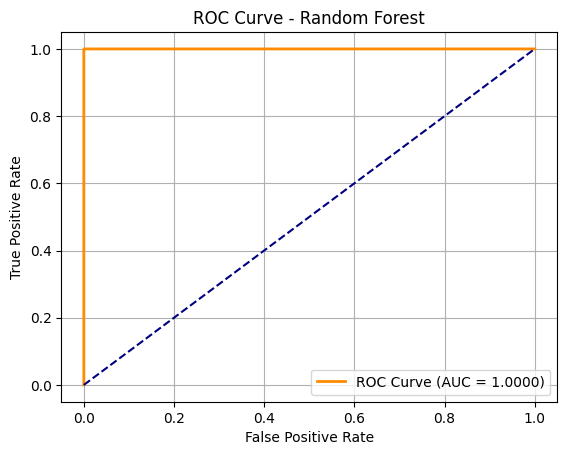

In [15]:
#ROC curve
from sklearn.metrics import roc_curve, auc
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

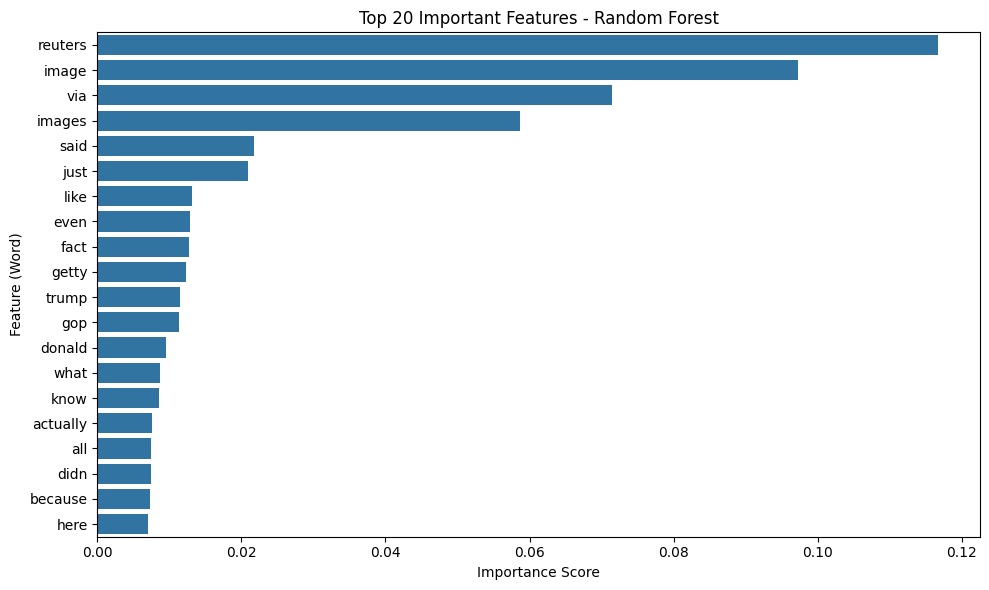

In [16]:
#Feature Importance Plot
importances = rf_model.feature_importances_
# Corrected the variable name from 'vectorizer' to 'tfidf_vectorizer'
feature_names = tfidf_vectorizer.get_feature_names_out()
# Top 20 important features
indices = np.argsort(importances)[-20:][::-1]
top_features = [feature_names[i] for i in indices]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=top_features)
plt.title("Top 20 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature (Word)")
plt.tight_layout()
plt.show()

<ipython-input-17-a9ae0840a7a4>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette="viridis")


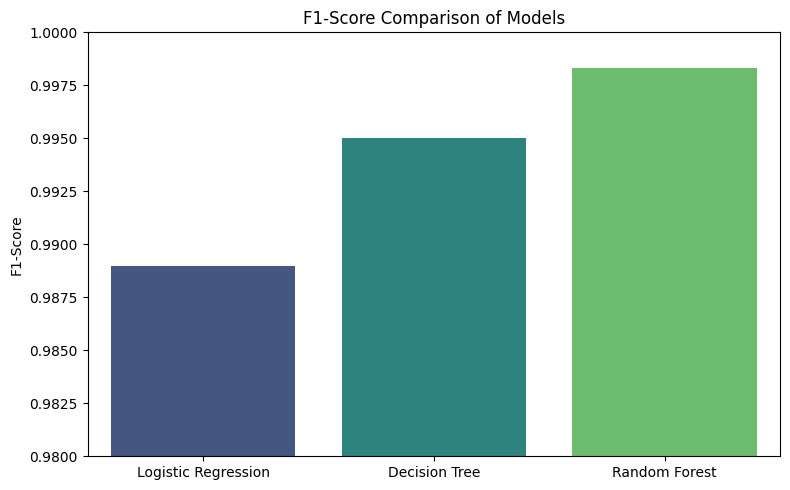

In [17]:
#Model Performance Comparison (Bar Chart)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
f1_scores = [0.9890, 0.9950, 0.9983]
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=f1_scores, palette="viridis")
plt.title("F1-Score Comparison of Models")
plt.ylabel("F1-Score")
plt.ylim(0.98, 1.0)
plt.tight_layout()
plt.show()

In [18]:
# Print Top 10 Features with highest importance
for i in range(10):
    print(f"{i+1}. {top_features[i]} - Importance Score: {importances[indices[i]]:.4f}")

1. reuters - Importance Score: 0.1167
2. image - Importance Score: 0.0973
3. via - Importance Score: 0.0715
4. images - Importance Score: 0.0587
5. said - Importance Score: 0.0217
6. just - Importance Score: 0.0209
7. like - Importance Score: 0.0132
8. even - Importance Score: 0.0129
9. fact - Importance Score: 0.0127
10. getty - Importance Score: 0.0122


**Exploratory Data Analysis(EDA)**

<ipython-input-19-e2f128baccb4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='coolwarm')


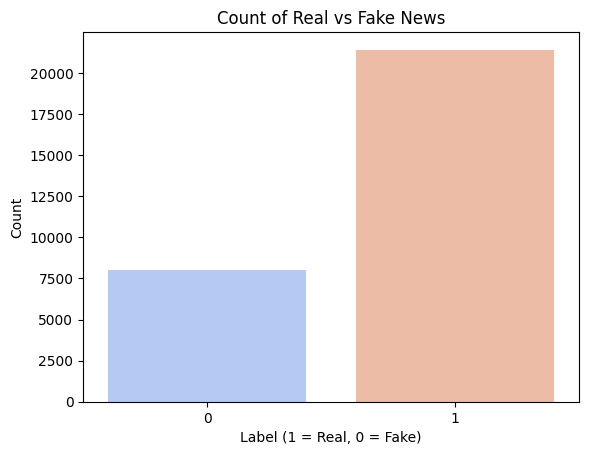

In [19]:
# 1. Univariate Analysis:
#a) Target Variable Distribution
# Distribution of real vs fake
sns.countplot(data=df, x='label', palette='coolwarm')
plt.title('Count of Real vs Fake News')
plt.xlabel('Label (1 = Real, 0 = Fake)')
plt.ylabel('Count')
plt.show()

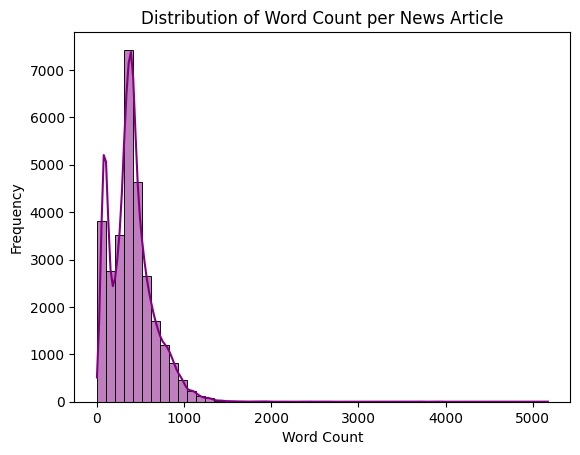

In [20]:
#b) Word Count per Article
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Word Count per News Article')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

<ipython-input-21-3d1d4d43d846>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', palette='Set2')


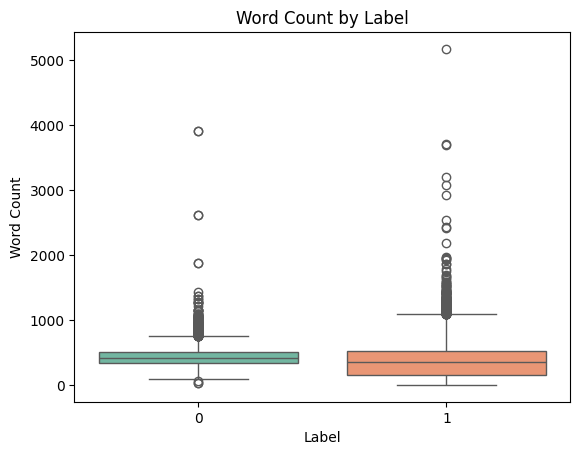

In [21]:
#c) Boxplot of Word Count
sns.boxplot(data=df, x='label', y='word_count', palette='Set2')
plt.title('Word Count by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.show()

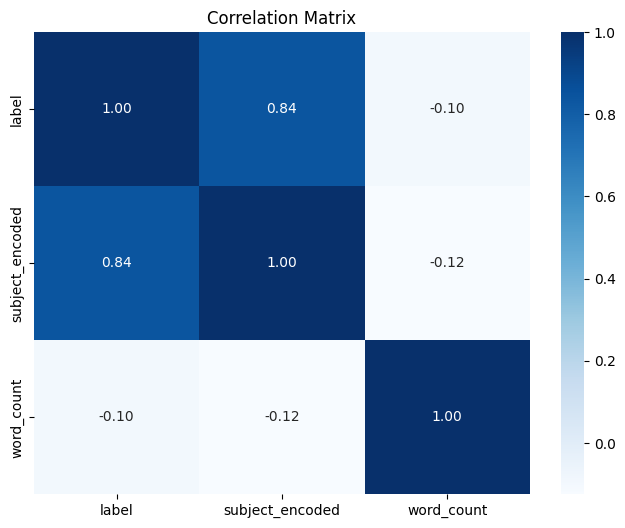

In [22]:
#2. Bivariate / Multivariate Analysis
#a) Correlation Matrix (Numerical features)
# For numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**Semi Supervised Learning**

In [23]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset
df = pd.read_csv("/content/news.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dropna(subset=["title", "text", "label"], inplace=True)

# 2. Label Encoding (FAKE = 0, TRUE = 1)
df['label'] = df['label'].map({"FAKE": 0, "TRUE": 1})

# 3. Text Cleaning Function
def clean_text(text):
    manual_stopwords = {
        'the','and','is','in','to','of','for','on','with','as','by','at','from',
        'that','this','an','it','be','are','was','were','or','which','a','but',
        'not','have','has','had','they','their','you','i','we','he','she','his',
        'her','them','its','will','would','can','could','should','may','might',
        'about','into','over','after','before','during','more','most','some','such',
        'no','nor','only'
    }
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in manual_stopwords]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

# 4. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_all = tfidf.fit_transform(df['clean_text'])

y_all = df['label'].values

# 5. Split labeled and unlabeled data
X_train_labeled, X_test, y_train_labeled, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

# Further split training data to create unlabeled pool
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(X_train_labeled, y_train_labeled, test_size=0.6, stratify=y_train_labeled, random_state=42)

# Create combined dataset with unlabeled labels as -1
y_combined = np.concatenate([y_labeled, [-1] * len(y_unlabeled)])
X_combined = np.vstack([X_labeled.toarray(), X_unlabeled.toarray()])

# 6. Define base model
base_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 7. Self-training with high threshold
self_training_model = SelfTrainingClassifier(base_model,criterion='threshold',threshold=0.95)

# 8. Fit the model
self_training_model.fit(X_combined, y_combined)

# 9. Evaluate
# Evaluate base model (trained only on labeled data)
base_model.fit(X_labeled, y_labeled)
y_pred_base = base_model.predict(X_test)
y_pred_self = self_training_model.predict(X_test)

print("✅ Supervised Accuracy (before self-training):", round(accuracy_score(y_test, y_pred_base), 4))
print("✅ Semi-Supervised Accuracy (after self-training):", round(accuracy_score(y_test, y_pred_self), 4))
print("\n🧾 Classification Report (Semi-Supervised):\n")
print(classification_report(y_test, y_pred_self))


✅ Supervised Accuracy (before self-training): 0.9993
✅ Semi-Supervised Accuracy (after self-training): 0.9993

🧾 Classification Report (Semi-Supervised):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      5891
   macro avg       1.00      1.00      1.00      5891
weighted avg       1.00      1.00      1.00      5891



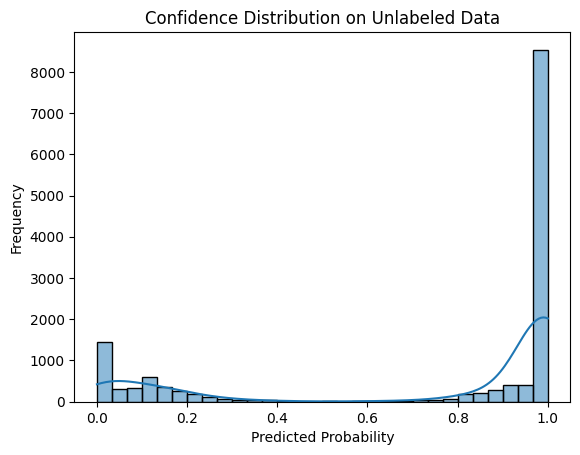

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(self_training_model.predict_proba(X_unlabeled)[:, 1], bins=30, kde=True)
plt.title("Confidence Distribution on Unlabeled Data")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()


In [25]:
print("Number of pseudo-labeled samples used:", (self_training_model.labeled_iter_[-1]))


Number of pseudo-labeled samples used: 1


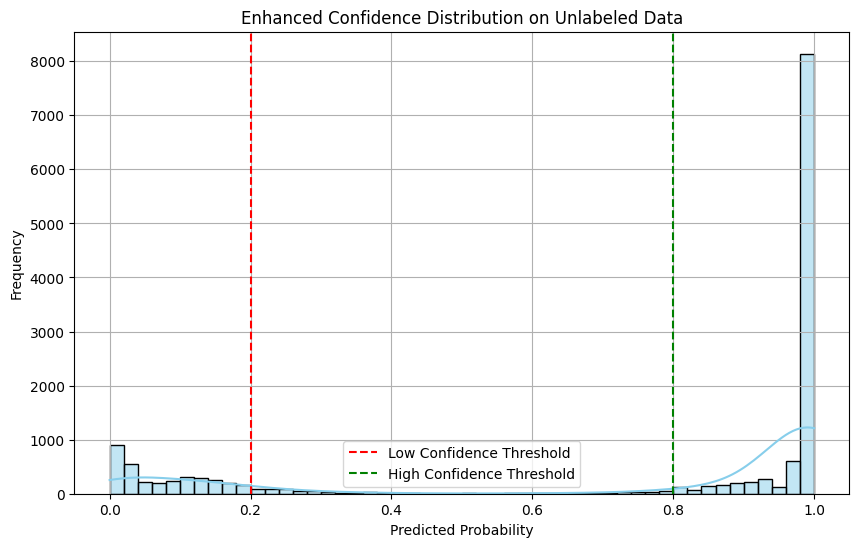

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
probs = self_training_model.predict_proba(X_unlabeled)[:, 1]
sns.histplot(probs, bins=50, kde=True, color='skyblue')
plt.axvline(x=0.2, color='red', linestyle='--', label='Low Confidence Threshold')
plt.axvline(x=0.8, color='green', linestyle='--', label='High Confidence Threshold')
plt.title("Enhanced Confidence Distribution on Unlabeled Data")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

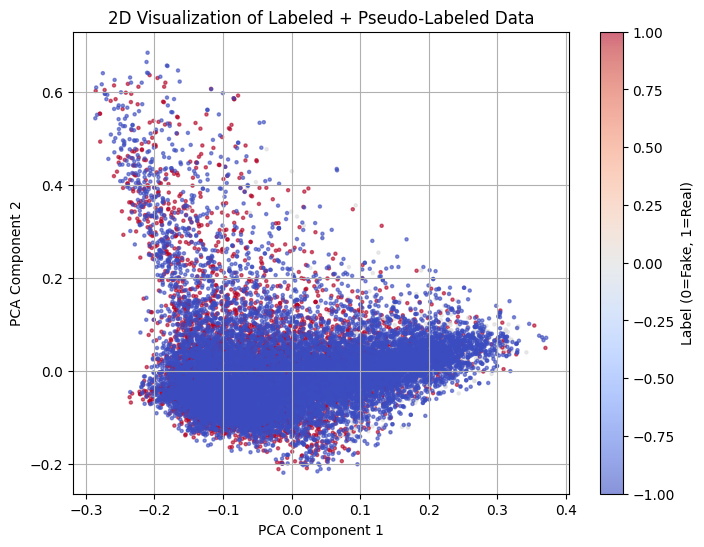

In [28]:
#Add PCA for Visualization
from sklearn.decomposition import PCA
# Remove .toarray() since X_combined is already a numpy array
X_2D = PCA(n_components=2).fit_transform(X_combined)

plt.figure(figsize=(8,6))
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y_combined, cmap='coolwarm', s=5, alpha=0.6)
plt.title("2D Visualization of Labeled + Pseudo-Labeled Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Label (0=Fake, 1=Real)")
plt.grid(True)
plt.show()

In [29]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.0 MB/s eta 0:00:00


In [31]:
import gradio as gr
import joblib
import re
import string
import pandas as pd

# Load saved model and vectorizer
rf_model = joblib.load('random_forest_model.pkl')
tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Stopwords used in training
manual_stopwords = {
    'the', 'and', 'is', 'in', 'to', 'of', 'for', 'on', 'with', 'as', 'by',
    'at', 'from', 'that', 'this', 'an', 'it', 'be', 'are', 'was', 'were',
    'or', 'which', 'a', 'but', 'not', 'have', 'has', 'had', 'they', 'their',
    'you', 'i', 'we', 'he', 'she', 'his', 'her', 'them', 'its', 'will', 'would',
    'can', 'could', 'should', 'may', 'might', 'about', 'into', 'over', 'after',
    'before', 'during', 'more', 'most', 'some', 'such', 'no', 'nor', 'only'
}

# Cleaning function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in manual_stopwords]
    return ' '.join(tokens)

# Prediction function
def predict_news(text):
    cleaned = clean_text(text)
    tfidf_input = tfidf_vectorizer.transform([cleaned])
    prediction = rf_model.predict(tfidf_input)[0]
    return "Fake" if prediction == 0 else "Real"

# Gradio interface
iface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=7, placeholder="Enter the news article text..."),
    outputs=gr.Textbox(label="Prediction"),
    title="Fake News Detection",
    description="Enter a news article's content to check if it's real or fake using a Random Forest Classifier."
)

iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f0ee8f067868372ca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
